<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/04_pytorch_custom_datasets_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. PyTorch Custom Datasets Exercises Template

Welcome to the 04. PyTorch Custom Datasets exercise template.

The best way to practice PyTorch code is to write more PyTorch code.

So read the original notebook and try to complete the exercises by writing code where it's required.

Feel free to reference the original resources whenever you need but should practice writing all of the code yourself.

## Resources

1. These exercises/solutions are based on [notebook 04 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/04_pytorch_custom_datasets/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/vsFMF9wqWx0).
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [71]:
# Check for GPU
!nvidia-smi

Thu Nov 27 14:52:35 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.94                 Driver Version: 560.94         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3070 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   42C    P8              8W /  100W |     446MiB /   8192MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [72]:
# Import torch
import torch
from torch import nn

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.8.0+cu128


'cuda'

## 1. Our models are underperforming (not fitting the data well). What are 3 methods for preventing underfitting? Write them down and explain each with a sentence.

1. Add more data to train the model.
2. Change models architecture, add more neurons and layers. It will prolong the training time but may yield better resutls.
3. Using different transformation of the used pictures - adding more pixels to train the network would allow the system to learn more patterns, but also will be more computation costly.

## 2. Recreate the data loading functions we built in [sections 1, 2, 3 and 4 of notebook 04](https://www.learnpytorch.io/04_pytorch_custom_datasets/). You should have train and test `DataLoader`'s ready to use.

In [73]:
# 1. Get data
import requests
import zipfile
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"{image_path} dictionary already exists")
else:
    print(f"{image_path} directory does not exist. Creating one in progess...")
    image_path.mkdir(parents=True, exist_ok=True)

    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data")       
        f.write(request.content)

    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

data\pizza_steak_sushi dictionary already exists


In [74]:
# 2. Become one with the data
import os

def walk_through_dir(dir_path):
  """Walks through dir_path returning file counts of its contents."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'.


In [75]:
# Setup train and testing paths

train_dir = image_path / "train"
test_dir  = image_path / "test"

Number of available images: 300

Image class:  pizza
Image height: 512
Image width:  512


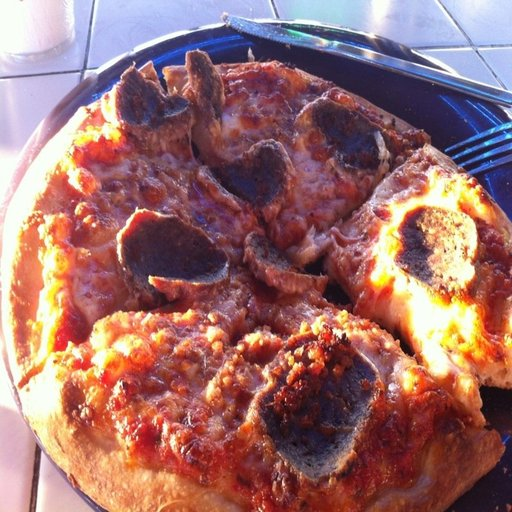

In [76]:
# Visualize an image
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path_list = list( image_path.glob("*/*/*.jpg") )
print( f"Number of available images: {len(image_path_list)}\n"  )

random_image_path = random.choice(image_path_list)
image_class = random_image_path.parent.stem

img = Image.open(random_image_path)
img_array = np.asarray(img)

print(f"Image class:  {image_class}")
print(f"Image height: {img.height}")
print(f"Image width:  {img.width}")
img

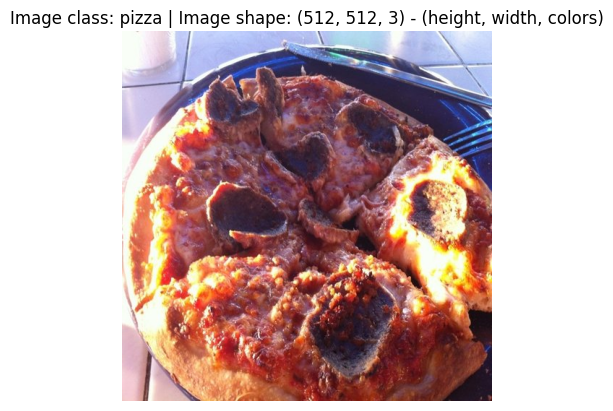

In [77]:
# Do the image visualization with matplotlib

plt.title(f"Image class: {image_class} | Image shape: {np.shape(img_array)} - (height, width, colors)")
plt.imshow(img_array)
plt.axis(False)
plt.show()

We've got some images in our folders.

Now we need to make them compatible with PyTorch by:
1. Transform the data into tensors.
2. Turn the tensor data into a `torch.utils.data.Dataset` and later a `torch.utils.data.DataLoader`.

In [78]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [79]:
# 3.1 Transforming data with torchvision.transforms

data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

data_transform(img).shape

torch.Size([3, 64, 64])

In [80]:
# Write transform for turning images into tensors


In [81]:
# Write a function to plot transformed images

def plot_transformed_images(image_paths, transform, n=1, seed=None):

    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)

    for image_path in random_image_paths:
        with Image.open(image_path) as f:

            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].set_title(f"Original size: {f.size}")
            ax[0].imshow(f)
            ax[0].axis("off")

            transformed_image = transform(f).permute(1,2,0)
            ax[1].set_title(f"Transformed\nsize: {transformed_image.shape}")
            ax[1].imshow(transformed_image)
            ax[1].axis("off")

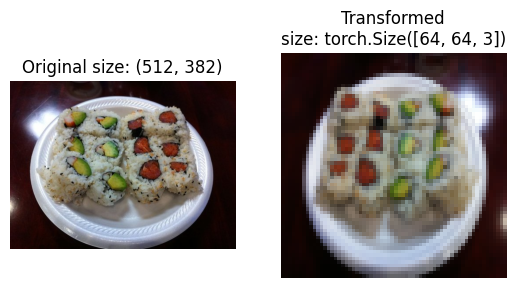

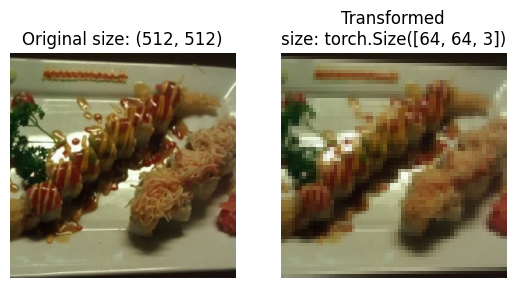

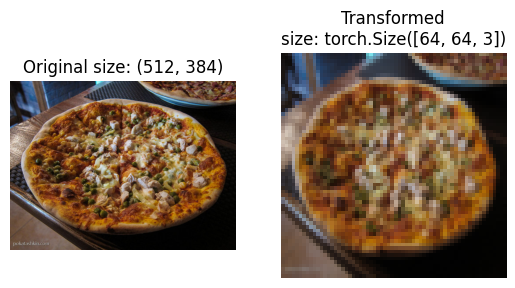

In [82]:
plot_transformed_images(image_path_list, transform=data_transform, n=3)


### Load image data using `ImageFolder`

In [83]:
# Use ImageFolder to create dataset(s)

from torchvision import datasets


In [84]:
train_data = datasets.ImageFolder(
    root=train_dir,
    transform=data_transform,
    target_transform=None
)

test_data = datasets.ImageFolder(
    root=test_dir,
    transform=data_transform
)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 225
    Root location: data\pizza_steak_sushi\train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 75
    Root location: data\pizza_steak_sushi\test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [85]:
# Get class names as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [86]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [87]:
# Check the lengths of each dataset
len(train_data), len(test_data)

(225, 75)

In [88]:
# Turn train and test Datasets into DataLoaders

from torch.utils.data import DataLoader
BATCH_SIZE = 1
NUM_WORKERS = os.cpu_count()
print(f"Creating DataLoader's with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")

Creating DataLoader's with batch size 1 and 12 workers.


In [89]:
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False
)

In [90]:
# How many batches of images are in our data loaders?

img, label = next(iter(train_dataloader))

# Batch size will now be 1, try changing the batch_size parameter above and see what happens
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


## 3. Recreate `model_0` we built in section 7 of notebook 04.

In [91]:
class TinyVGG(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d( in_channels=input_shape,
                       out_channels=hidden_units,
                       kernel_size=3,
                       stride=1,
                       padding=1  ),
            nn.ReLU(),
            nn.Conv2d( in_channels=hidden_units,
                       out_channels=hidden_units,
                       kernel_size=3,
                       stride=1,
                       padding=1  ),            
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)          )
        
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d( hidden_units, hidden_units, kernel_size=3, padding=1  ),
            nn.ReLU(),
            nn.Conv2d( hidden_units, hidden_units, kernel_size=3, padding=1  ),
            nn.ReLU(),
            nn.MaxPool2d(2)         )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features= hidden_units*16*16,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

In [92]:
model_0 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(train_data.classes)).to(device)

In [93]:
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

## 4. Create training and testing functions for `model_0`.

In [94]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
  
    # Put the model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader and data batches

    for batch, (X, y) in enumerate(dataloader):
  
      # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      y_pred = model(X)

      # 2. Calculate and accumulate loss
      loss = loss_fn(y_pred, y)
      train_loss += loss.item()

      # 3. Optimizer zero grad 
      optimizer.zero_grad()

      # 4. Loss backward 
      loss.backward()

      # 5. Optimizer step
      optimizer.step()

      # Calculate and accumualte accuracy metric across all batches
      y_pred_class = torch.argmax( torch.softmax(y_pred, dim=1) )
      train_acc += (y_pred_class==y).sum().item()/len(y_pred)
      

    # Adjust metrics to get average loss and average accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [95]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
  
  # Put model in eval mode
  model.eval()

  # Setup the test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference context manager
  with torch.inference_mode():
  
    # Loop through DataLoader batches
    for batch, (X, y) in enumerate(dataloader):

      # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      test_pred_logits = model(X)

      # 2. Calculuate and accumulate loss
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      # Calculate and accumulate accuracy
      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += ( (test_pred_labels==y).sum().item()/len(test_pred_labels) )

    
  # Adjust metrics to get average loss and accuracy per batch

  test_loss = test_loss / len(dataloader)
  test_acc  = test_acc  / len(dataloader)
  return test_loss, test_acc

In [103]:
from tqdm.auto import tqdm
from IPython.display import clear_output

In [108]:
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss,
          epochs: int = 5):
  
  # Create results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  # Loop through the training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
    # Train step
    train_loss, train_acc = train_step(model=model, 
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer)
    # Test step
    test_loss, test_acc = test_step(model=model, 
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn)
    
    # clear_output(wait=True)
    # Print out what's happening
    print(f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
    )

    # Update the results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # Return the results dictionary
  return results

## 5. Try training the model you made in exercise 3 for 5, 20 and 50 epochs, what happens to the results?
* Use `torch.optim.Adam()` with a learning rate of 0.001 as the optimizer. 

In [105]:
from timeit import default_timer as timer 

In [106]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Train for 5 epochs
NUM_EPOCHS = 5

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
start_time = timer()

# Train model_0 
model_0_results = train(model = model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

100%|██████████| 5/5 [01:29<00:00, 17.92s/it]

Epoch: 5 | train_loss: 1.0989 | train_acc: 0.3422 | test_loss: 1.1006 | test_acc: 0.3333
Total training time: 89.590 seconds


In [ ]:
# Train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# NUM_EPOCHS = 20

# # Recreate an instance of TinyVGG
# model_0 = TinyVGG(input_shape=3,
#                   hidden_units=10,
#                   output_shape=len(train_data.classes)).to(device)

# loss_fn = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# # Start the timer
# start_time = timer()

# # Train model_0 
# model_0_results_20 = train(model = model_0,
#                         train_dataloader=train_dataloader,
#                         test_dataloader=test_dataloader,
#                         optimizer=optimizer,
#                         loss_fn=loss_fn,
#                         epochs=NUM_EPOCHS)

# # End the timer and print out how long it took
# end_time = timer()
# print(f"Total training time: {end_time-start_time:.3f} seconds")

  5%|▌         | 1/20 [00:18<06:00, 18.98s/it]

Epoch: 1 | train_loss: 1.1182 | train_acc: 0.2933 | test_loss: 1.0963 | test_acc: 0.4133


 10%|█         | 2/20 [00:35<05:18, 17.71s/it]

Epoch: 2 | train_loss: 1.1012 | train_acc: 0.3289 | test_loss: 1.0996 | test_acc: 0.2533


 15%|█▌        | 3/20 [00:51<04:47, 16.93s/it]

...

Epoch: 18 | train_loss: 0.7366 | train_acc: 0.6711 | test_loss: 1.0818 | test_acc: 0.3733


 95%|█████████▌| 19/20 [05:19<00:15, 15.80s/it]

Epoch: 19 | train_loss: 0.7504 | train_acc: 0.6667 | test_loss: 1.0750 | test_acc: 0.4800


100%|██████████| 20/20 [05:34<00:00, 16.74s/it]

Epoch: 20 | train_loss: 0.6920 | train_acc: 0.6844 | test_loss: 1.0779 | test_acc: 0.4933
Total training time: 334.877 seconds


In [ ]:
# Train for 50 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# NUM_EPOCHS = 50

# # Recreate an instance of TinyVGG
# model_0 = TinyVGG(input_shape=3,
#                   hidden_units=10,
#                   output_shape=len(train_data.classes)).to(device)

# loss_fn = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# # Start the timer
# start_time = timer()

# # Train model_0 
# model_0_results_50 = train(model = model_0,
#                         train_dataloader=train_dataloader,
#                         test_dataloader=test_dataloader,
#                         optimizer=optimizer,
#                         loss_fn=loss_fn,
#                         epochs=NUM_EPOCHS)

# # End the timer and print out how long it took
# end_time = timer()
# print(f"Total training time: {end_time-start_time:.3f} seconds")

  2%|▏         | 1/50 [00:15<12:37, 15.45s/it]

Epoch: 1 | train_loss: 1.1182 | train_acc: 0.2933 | test_loss: 1.0963 | test_acc: 0.4133


  4%|▍         | 2/50 [00:30<12:23, 15.49s/it]

Epoch: 2 | train_loss: 1.1008 | train_acc: 0.3289 | test_loss: 1.0996 | test_acc: 0.2533


  6%|▌         | 3/50 [00:46<12:06, 15.45s/it]

...

Epoch: 48 | train_loss: 1.0987 | train_acc: 0.3467 | test_loss: 1.1024 | test_acc: 0.3333


 98%|█████████▊| 49/50 [12:52<00:16, 16.02s/it]

Epoch: 49 | train_loss: 1.0986 | train_acc: 0.3467 | test_loss: 1.1021 | test_acc: 0.3333


100%|██████████| 50/50 [13:08<00:00, 15.76s/it]

Epoch: 50 | train_loss: 1.0988 | train_acc: 0.3467 | test_loss: 1.1020 | test_acc: 0.3333
Total training time: 788.085 seconds


It looks like our model is starting to overfit towards the end (performing far better on the training data than on the testing data).

In order to fix this, we'd have to introduce ways of preventing overfitting.

## 6. Double the number of hidden units in your model and train it for 20 epochs, what happens to the results?

In [109]:
# Double the number of hidden units and train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 20

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=3,
                  hidden_units=20,
                  output_shape=len(train_data.classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
start_time = timer()

# Train model_0 
model_0_results_hu20_e50 = train(model = model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"\n Total training time: {end_time-start_time:.3f} seconds")

  5%|▌         | 1/20 [00:18<05:59, 18.94s/it]

Epoch: 1 | train_loss: 1.1016 | train_acc: 0.4178 | test_loss: 1.0707 | test_acc: 0.2933


 10%|█         | 2/20 [00:36<05:24, 18.03s/it]

Epoch: 2 | train_loss: 0.9968 | train_acc: 0.5556 | test_loss: 1.0293 | test_acc: 0.4533


 15%|█▌        | 3/20 [00:54<05:04, 17.94s/it]

...

Epoch: 18 | train_loss: 0.2491 | train_acc: 0.8978 | test_loss: 2.0564 | test_acc: 0.4800


 95%|█████████▌| 19/20 [05:27<00:16, 16.85s/it]

Epoch: 19 | train_loss: 0.3593 | train_acc: 0.8711 | test_loss: 1.7360 | test_acc: 0.4533


100%|██████████| 20/20 [05:44<00:00, 17.22s/it]

Epoch: 20 | train_loss: 0.2537 | train_acc: 0.8978 | test_loss: 2.4095 | test_acc: 0.4267

 Total training time: 344.488 seconds


It looks like the model is still overfitting, even when changing the number of hidden units.

To fix this, we'd have to look at ways to prevent overfitting with our model.

## 7. Double the data you're using with your model from step 6 and train it for 20 epochs, what happens to the results?
* **Note:** You can use the [custom data creation notebook](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb) to scale up your Food101 dataset.
* You can also find the [already formatted double data (20% instead of 10% subset) dataset on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip), you will need to write download code like in exercise 2 to get it into this notebook.

In [110]:
# Download 20% data for Pizza/Steak/Sushi from GitHub
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi_20_percent"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
# Download pizza, steak, sushi data
with open(data_path / "pizza_steak_sushi_20_percent.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
    print("Downloading pizza, steak, sushi 20% data...")
    f.write(request.content)

# Unzip pizza, steak, sushi data
with zipfile.ZipFile(data_path / "pizza_steak_sushi_20_percent.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi 20% data...") 
    zip_ref.extractall(image_path)

Did not find data\pizza_steak_sushi_20_percent directory, creating one...
Unzipping pizza, steak, sushi 20% data...


In [111]:
# See how many images we have
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi_20_percent'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi_20_percent\test'.
There are 0 directories and 46 images in 'data\pizza_steak_sushi_20_percent\test\pizza'.
There are 0 directories and 58 images in 'data\pizza_steak_sushi_20_percent\test\steak'.
There are 0 directories and 46 images in 'data\pizza_steak_sushi_20_percent\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi_20_percent\train'.
There are 0 directories and 154 images in 'data\pizza_steak_sushi_20_percent\train\pizza'.
There are 0 directories and 146 images in 'data\pizza_steak_sushi_20_percent\train\steak'.
There are 0 directories and 150 images in 'data\pizza_steak_sushi_20_percent\train\sushi'.


Excellent, we now have double the training and testing images... 

In [112]:
# Create the train and test paths
train_data_20_percent_path = image_path / "train"
test_data_20_percent_path = image_path / "test"

train_data_20_percent_path, test_data_20_percent_path

(WindowsPath('data/pizza_steak_sushi_20_percent/train'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test'))

In [115]:
# Turn the 20 percent datapaths into Datasets and DataLoaders
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

simple_transform = transforms.Compose([
  transforms.Resize((64, 64)),                                     
  transforms.ToTensor()
])

# Create datasets

train_data = datasets.ImageFolder(root=train_data_20_percent_path, # target folder of images
                                  transform=data_transform, # transforms to perform on data (images)
                                  target_transform=None) # transforms to perform on labels (if necessary)

test_data = datasets.ImageFolder(root=test_data_20_percent_path, 
                                 transform=data_transform)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")


# Create dataloaders
BATCH_SIZE = 1
NUM_WORKERS = os.cpu_count()

train_dataloader = DataLoader(dataset=train_data, 
                              batch_size=BATCH_SIZE, # how many samples per batch?
                              num_workers=NUM_WORKERS, # how many subprocesses to use for data loading? (higher = more)
                              shuffle=True) # shuffle the data?

test_dataloader = DataLoader(dataset=test_data, 
                             batch_size=BATCH_SIZE, 
                             num_workers=NUM_WORKERS, 
                             shuffle=False) # don't usually need to shuffle testing data

train_dataloader, test_dataloader


Train data:
Dataset ImageFolder
    Number of datapoints: 450
    Root location: data\pizza_steak_sushi_20_percent\train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 150
    Root location: data\pizza_steak_sushi_20_percent\test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


(<torch.utils.data.dataloader.DataLoader at 0x264f56ead70>,
 <torch.utils.data.dataloader.DataLoader at 0x264f578af90>)

In [117]:
# Train a model with increased amount of data
torch.manual_seed(42)
torch.cuda.manual_seed(42)


NUM_EPOCHS = 10

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
start_time = timer()

# Train model_0 
model_0_results_hu10_e10 = train(model = model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"\n Total training time: {end_time-start_time:.3f} seconds")

 10%|█         | 1/10 [00:19<02:56, 19.57s/it]

Epoch: 1 | train_loss: 1.1059 | train_acc: 0.3489 | test_loss: 1.0986 | test_acc: 0.3200


 20%|██        | 2/10 [00:37<02:30, 18.81s/it]

Epoch: 2 | train_loss: 1.0995 | train_acc: 0.3022 | test_loss: 1.0988 | test_acc: 0.3067


 30%|███       | 3/10 [00:55<02:09, 18.44s/it]

...

Epoch: 8 | train_loss: 0.9061 | train_acc: 0.5822 | test_loss: 0.8914 | test_acc: 0.5867


 90%|█████████ | 9/10 [02:45<00:18, 18.39s/it]

Epoch: 9 | train_loss: 0.8854 | train_acc: 0.5978 | test_loss: 0.9123 | test_acc: 0.5467


100%|██████████| 10/10 [03:03<00:00, 18.33s/it]

Epoch: 10 | train_loss: 0.8925 | train_acc: 0.5822 | test_loss: 0.8827 | test_acc: 0.5933

 Total training time: 183.298 seconds


## 8. Make a prediction on your own custom image of pizza/steak/sushi (you could even download one from the internet) with your trained model from exercise 7 and share your prediction. 
* Does the model you trained in exercise 7 get it right? 
* If not, what do you think you could do to improve it?